# Optimal $\Delta$ Analysis & Shift Violation Comparison

### Imports and Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from eval_helpers import compute_cycle_times

In [2]:
schedule = pd.read_csv('../availabilities/availabilities_advanced.csv')
schedule['StartTime'] = pd.to_datetime(schedule['StartTime'], format='%H:%M:%S').dt.time
schedule['EndTime'] = pd.to_datetime(schedule['EndTime'], format='%H:%M:%S').dt.time
schedule['BreakStart'] = pd.to_datetime(schedule['BreakStart'], format='%H:%M:%S').dt.time

In [3]:
def count_violations(log_path, schedule_df):
    df = pd.read_csv(log_path, parse_dates=['time:timestamp'])
    completes = df[(df['concept:name'].str.startswith('W_')) & (df['lifecycle:transition'] == 'complete')].copy()
    
    completes['DayId'] = (completes['time:timestamp'].dt.normalize() - pd.Timestamp('2016-01-01')).dt.days % 7
    completes['EventTime'] = completes['time:timestamp'].dt.time
    
    merged = completes.merge(schedule_df, left_on=['org:resource', 'DayId'], right_on=['Resource', 'DayId'], how='left')
    
    shift_violations = len(merged[(merged['EventTime'] > merged['EndTime']) | (merged['EventTime'] < merged['StartTime'])])
    merged['BreakEnd'] = pd.to_datetime(merged['BreakStart'].astype(str), format='%H:%M:%S', errors='coerce') + pd.to_timedelta(merged['DurationMin'], unit='m')
    merged['BreakEnd'] = merged['BreakEnd'].dt.time
    break_violations = len(merged[(merged['EventTime'] > merged['BreakStart']) & (merged['EventTime'] < merged['BreakEnd'])])
    
    return shift_violations + break_violations

def get_clean_merged_tasks(sim_path):
    """Loads a log, extracts W_ tasks, and pairs starts and completes 1-to-1."""
    df = pd.read_csv(sim_path)
    df['time:timestamp'] = pd.to_datetime(df['time:timestamp'])
    
    w_df = df[df['concept:name'].str.startswith('W_')].copy()
    w_df = w_df.sort_values(by=['case:concept:name', 'concept:name', 'time:timestamp'])
    
    starts = w_df[w_df['lifecycle:transition'] == 'start'].copy()
    completes = w_df[w_df['lifecycle:transition'] == 'complete'].copy()
    
    starts['rank'] = starts.groupby(['case:concept:name', 'concept:name', 'org:resource']).cumcount()
    completes['rank'] = completes.groupby(['case:concept:name', 'concept:name', 'org:resource']).cumcount()

    merged = pd.merge(starts, completes, on=['case:concept:name', 'concept:name', 'org:resource', 'rank'], suffixes=('_s', '_c'))
    return df, merged

print("Setup Complete! Schedule and helpers loaded.")

Setup Complete! Schedule and helpers loaded.


### Monte Carlo Simulation

Throughput


ANALYZING: ADVANCED_LOCAL (Averaged over 10 runs)
Delta 1 | Averaged 10 runs | Events: 2579 | Vio: 28.4
Delta 2 | Averaged 10 runs | Events: 7980 | Vio: 120.6
Delta 3 | Averaged 10 runs | Events: 8685 | Vio: 124.3
Delta 4 | Averaged 10 runs | Events: 9152 | Vio: 148.8
Delta 5 | Averaged 10 runs | Events: 10177 | Vio: 147.2
Delta 7.5 | Averaged 10 runs | Events: 10718 | Vio: 187.2
Delta 10 | Averaged 10 runs | Events: 10682 | Vio: 179.9
Delta 12.5 | Averaged 10 runs | Events: 10908 | Vio: 177.1
Delta 15 | Averaged 10 runs | Events: 12590 | Vio: 216.8
Delta 20 | Averaged 10 runs | Events: 15020 | Vio: 226.7


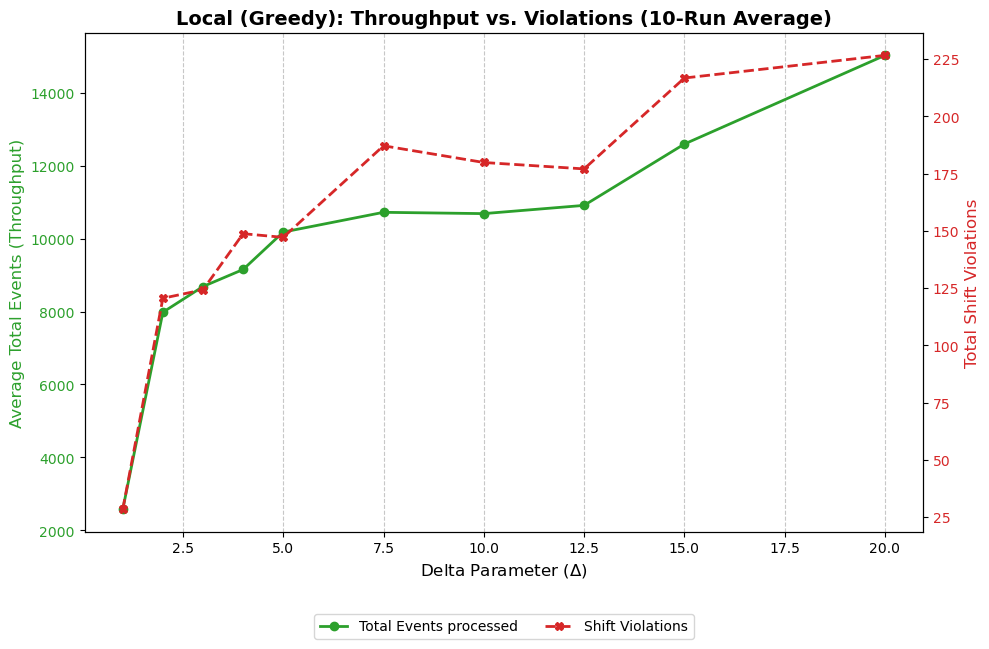


ANALYZING: ADVANCED_GLOBAL (Averaged over 10 runs)
Delta 1 | Averaged 10 runs | Events: 12 | Vio: 0.0
Delta 2 | Averaged 10 runs | Events: 3211 | Vio: 47.5
Delta 3 | Averaged 10 runs | Events: 3613 | Vio: 58.1
Delta 4 | Averaged 10 runs | Events: 3446 | Vio: 52.5
Delta 5 | Averaged 10 runs | Events: 4310 | Vio: 67.5
Delta 7.5 | Averaged 10 runs | Events: 6387 | Vio: 112.4
Delta 10 | Averaged 10 runs | Events: 6195 | Vio: 110.9
Delta 12.5 | Averaged 10 runs | Events: 7972 | Vio: 146.0
Delta 15 | Averaged 10 runs | Events: 8542 | Vio: 148.0
Delta 20 | Averaged 10 runs | Events: 10146 | Vio: 182.1


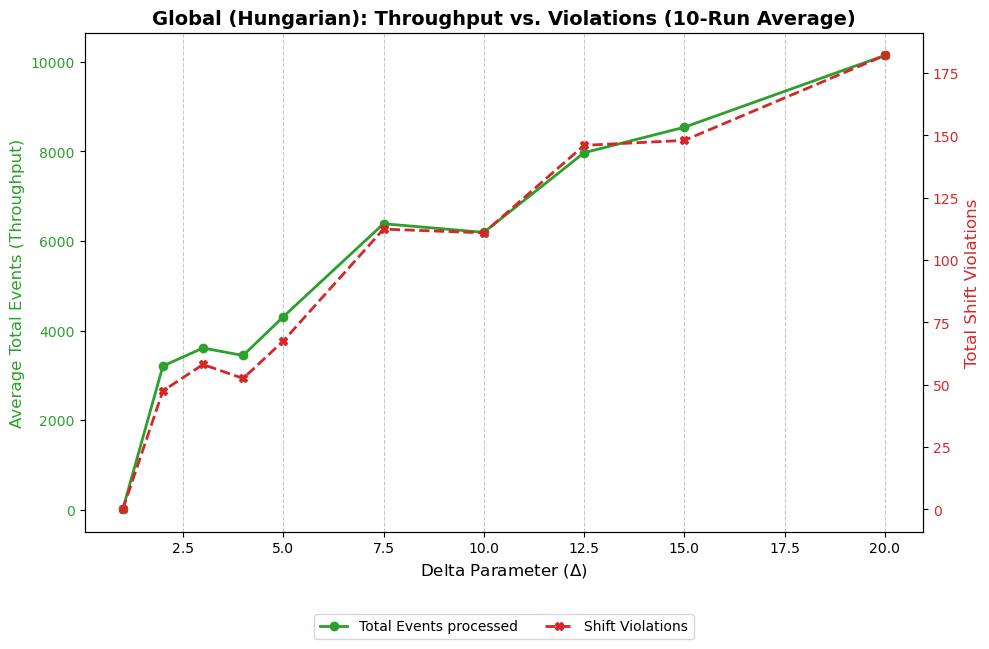

In [4]:
methods = ['advanced_local', 'advanced_global']
delta_values = [1, 2, 3, 4, 5, 7.5, 10, 12.5, 15, 20]

for method in methods:
    print(f"\n{'='*40}\nANALYZING: {method.upper()} (Averaged over 10 runs)\n{'='*40}")
    results = []
    
    for d in delta_values:
        run_events, run_vios = [], []
        
        for i in range(1, 11):
            log_path = f'../../sim_output/{method}/{i}/sim_log_adv_d{d}.csv'
            try:
                df = pd.read_csv(log_path, parse_dates=['time:timestamp'])
                total_events = len(df) 
                # total_events = df['case:concept:name'].nunique()
                total_violations = count_violations(log_path, schedule)
                
                run_events.append(total_events)
                run_vios.append(total_violations)
            except FileNotFoundError:
                pass 
        
        if run_events:
            avg_events_all_runs = np.mean(run_events)
            avg_vio_all_runs = np.mean(run_vios)
            results.append({
                'Delta': d, 
                'Total Events': avg_events_all_runs, 
                'Violations': avg_vio_all_runs
            })
            print(f"Delta {d} | Averaged {len(run_events)} runs | Events: {avg_events_all_runs:.0f} | Vio: {avg_vio_all_runs:.1f}")

    df_delta_results_throughput = pd.DataFrame(results)

    if not df_delta_results_throughput.empty:
        fig, ax1 = plt.subplots(figsize=(10, 6))
        color = '#2ca02c'
        ax1.set_xlabel(r'Delta Parameter ($\Delta$)', fontsize=12)
        ax1.set_ylabel('Average Total Events (Throughput)', color=color, fontsize=12)
        ax1.plot(df_delta_results_throughput['Delta'], df_delta_results_throughput['Total Events'], marker='o', color=color, linewidth=2, label='Total Events processed')
        ax1.tick_params(axis='y', labelcolor=color)
        ax1.grid(axis='x', linestyle='--', alpha=0.7)

        ax2 = ax1.twinx()  
        color = '#d62728'
        ax2.set_ylabel('Total Shift Violations', color=color, fontsize=12)  
        ax2.plot(df_delta_results_throughput['Delta'], df_delta_results_throughput['Violations'], marker='X', linestyle='--', color=color, linewidth=2, label='Shift Violations')
        ax2.tick_params(axis='y', labelcolor=color)

        method_title = "Local (Greedy)" if "local" in method else "Global (Hungarian)"
        plt.title(f'{method_title}: Throughput vs. Violations (10-Run Average)', fontsize=14, fontweight='bold')
        fig.tight_layout()  
        
        lines_1, labels_1 = ax1.get_legend_handles_labels()
        lines_2, labels_2 = ax2.get_legend_handles_labels()
        ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)
        
        plt.savefig(f'files/monte_carlo_delta_analysis_{method}_throughput_final.pdf', format='pdf', bbox_inches='tight')
        plt.show()

Average Processing times


ANALYZING: ADVANCED_LOCAL (Averaged over 10 runs)
Delta 1 | Averaged 10 runs | CT: 1.19h | Vio: 28.4
Delta 2 | Averaged 10 runs | CT: 7.83h | Vio: 120.6
Delta 3 | Averaged 10 runs | CT: 8.60h | Vio: 124.3
Delta 4 | Averaged 10 runs | CT: 9.97h | Vio: 148.8
Delta 5 | Averaged 10 runs | CT: 10.98h | Vio: 147.2
Delta 7.5 | Averaged 10 runs | CT: 11.21h | Vio: 187.2
Delta 10 | Averaged 10 runs | CT: 11.70h | Vio: 179.9
Delta 12.5 | Averaged 10 runs | CT: 13.85h | Vio: 177.1
Delta 15 | Averaged 10 runs | CT: 13.82h | Vio: 216.8
Delta 20 | Averaged 10 runs | CT: 14.27h | Vio: 226.7


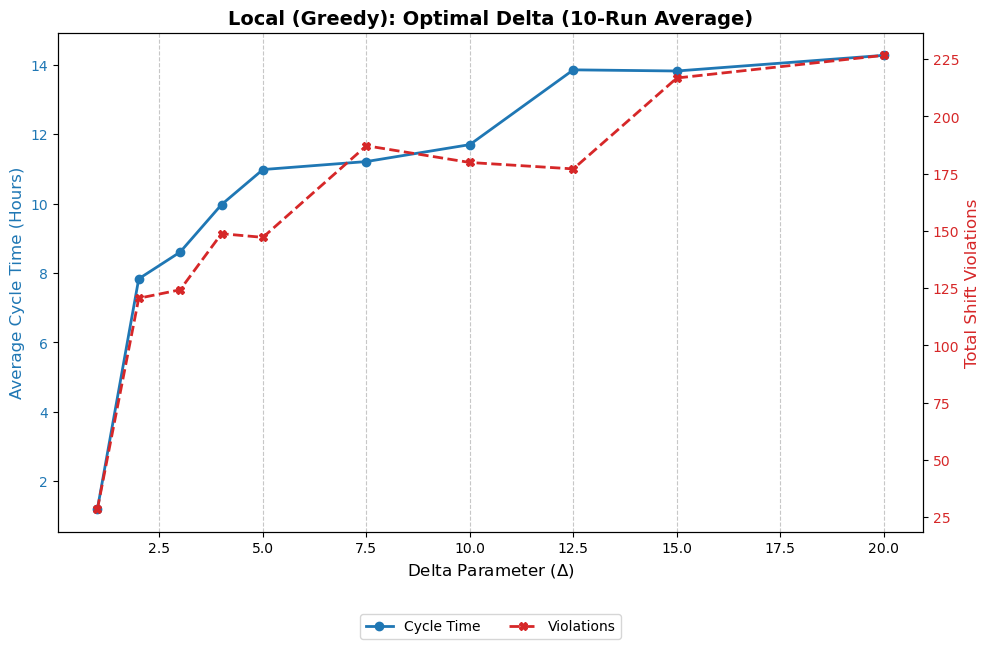


ANALYZING: ADVANCED_GLOBAL (Averaged over 10 runs)
Delta 1 | Averaged 10 runs | CT: 0.00h | Vio: 0.0
Delta 2 | Averaged 10 runs | CT: 1.55h | Vio: 47.5
Delta 3 | Averaged 10 runs | CT: 2.68h | Vio: 58.1
Delta 4 | Averaged 10 runs | CT: 1.86h | Vio: 52.5
Delta 5 | Averaged 10 runs | CT: 3.12h | Vio: 67.5
Delta 7.5 | Averaged 10 runs | CT: 5.49h | Vio: 112.4
Delta 10 | Averaged 10 runs | CT: 4.60h | Vio: 110.9
Delta 12.5 | Averaged 10 runs | CT: 5.88h | Vio: 146.0
Delta 15 | Averaged 10 runs | CT: 6.59h | Vio: 148.0
Delta 20 | Averaged 10 runs | CT: 7.42h | Vio: 182.1


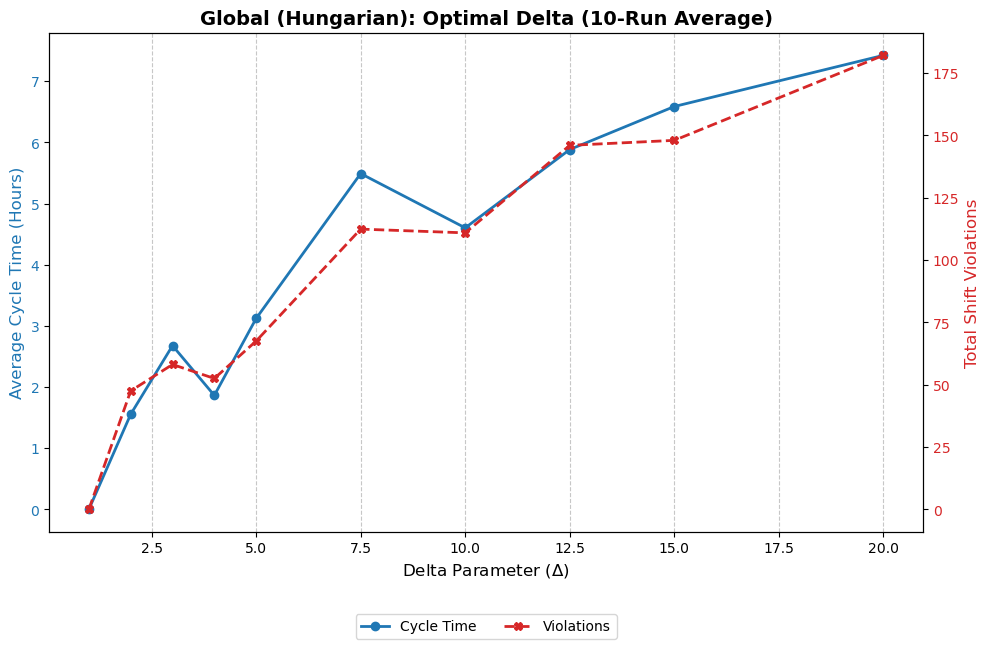

In [5]:
methods = ['advanced_local', 'advanced_global']
delta_values = [1, 2, 3, 4, 5, 7.5, 10, 12.5, 15, 20]

for method in methods:
    print(f"\n{'='*40}\nANALYZING: {method.upper()} (Averaged over 10 runs)\n{'='*40}")
    results = []
    
    for d in delta_values:
        run_cts, run_vios = [], []
        
        for i in range(1, 11):
            log_path = f'../../sim_output/{method}/{i}/sim_log_adv_d{d}.csv'
            try:
                df = pd.read_csv(log_path, parse_dates=['time:timestamp'])
                avg_cycle = compute_cycle_times(df).mean()
                total_violations = count_violations(log_path, schedule) 
                run_cts.append(avg_cycle)
                run_vios.append(total_violations)
            except FileNotFoundError:
                pass 
        
        if run_cts:
            avg_ct_all_runs = np.mean(run_cts)
            avg_vio_all_runs = np.mean(run_vios)
            results.append({
                'Delta': d, 'Cycle Time (hrs)': avg_ct_all_runs, 'Violations': avg_vio_all_runs
            })
            print(f"Delta {d} | Averaged {len(run_cts)} runs | CT: {avg_ct_all_runs:.2f}h | Vio: {avg_vio_all_runs:.1f}")

    df_delta_results_cycle_time = pd.DataFrame(results)

    if not df_delta_results_cycle_time.empty:
        fig, ax1 = plt.subplots(figsize=(10, 6))

        color = '#1f77b4'
        ax1.set_xlabel(r'Delta Parameter ($\Delta$)', fontsize=12)
        ax1.set_ylabel('Average Cycle Time (Hours)', color=color, fontsize=12)
        ax1.plot(df_delta_results_cycle_time['Delta'], df_delta_results_cycle_time['Cycle Time (hrs)'], marker='o', color=color, linewidth=2, label='Cycle Time')
        ax1.tick_params(axis='y', labelcolor=color)
        ax1.grid(axis='x', linestyle='--', alpha=0.7)

        ax2 = ax1.twinx()  
        color = '#d62728'
        ax2.set_ylabel('Total Shift Violations', color=color, fontsize=12)  
        ax2.plot(df_delta_results_cycle_time['Delta'], df_delta_results_cycle_time['Violations'], marker='X', linestyle='--', color=color, linewidth=2, label='Violations')
        ax2.tick_params(axis='y', labelcolor=color)

        method_title = "Local (Greedy)" if "local" in method else "Global (Hungarian)"
        plt.title(f'{method_title}: Optimal Delta (10-Run Average)', fontsize=14, fontweight='bold')
        fig.tight_layout()  
        
        lines_1, labels_1 = ax1.get_legend_handles_labels()
        lines_2, labels_2 = ax2.get_legend_handles_labels()
        ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)
        
        plt.savefig(f'files/monte_carlo_delta_analysis_{method}_final.pdf', format='pdf', bbox_inches='tight')
        plt.show()

### Analyse Schedule Violations

In [6]:
print("Aggregating Schedule Violations across 10 runs...")

schedule['StartSec'] = pd.to_timedelta(schedule['StartTime'].astype(str)).dt.total_seconds()
schedule['EndSec'] = pd.to_timedelta(schedule['EndTime'].astype(str)).dt.total_seconds()
schedule['BreakStartSec'] = pd.to_timedelta(schedule['BreakStart'].astype(str)).dt.total_seconds()
schedule['BreakEndSec'] = schedule['BreakStartSec'] + (schedule['DurationMin'] * 60)

strategies = {
    'Random': '../../sim_output/random/sim_log_Methods.RANDOM_{i}.csv',
    'Round Robin': '../../sim_output/round_robin/sim_log_Methods.ROUND_ROBIN_{i}.csv',
    'Shortest Queue': '../../sim_output/shortest_queue/sim_log_Methods.SHORTEST_QUEUE_{i}.csv',
    'Batching': '../../sim_output/batching/sim_log_Methods.BATCHING_{i}.csv',
    'Advanced Local': '../../sim_output/advanced_local/{i}/sim_log_adv_d5.csv', 
    'Advanced Global': '../../sim_output/advanced_global/{i}/sim_log_adv_d10.csv'
}

violation_results = []

for label, path_template in strategies.items():
    run_before, run_after, run_break, run_total = [], [], [], []
    
    for i in range(1, 11):
        path = path_template.format(i=i)
        try:
            _, merged = get_clean_merged_tasks(path)
            
            merged['DayId'] = (merged['time:timestamp_s'].dt.normalize() - pd.Timestamp('2016-01-01')).dt.days % 7
            merged['TaskStartSec'] = merged['time:timestamp_s'].dt.hour * 3600 + merged['time:timestamp_s'].dt.minute * 60 + merged['time:timestamp_s'].dt.second
            merged['TaskEndSec'] = merged['time:timestamp_c'].dt.hour * 3600 + merged['time:timestamp_c'].dt.minute * 60 + merged['time:timestamp_c'].dt.second
            
            merged_sch = merged.merge(schedule, left_on=['org:resource', 'DayId'], right_on=['Resource', 'DayId'], how='inner')
            
            viol_before = (merged_sch['TaskStartSec'] < merged_sch['StartSec']).sum()
            viol_after = (merged_sch['TaskEndSec'] > merged_sch['EndSec']).sum()
            viol_break = ((merged_sch['TaskStartSec'] < merged_sch['BreakEndSec']) & (merged_sch['TaskEndSec'] > merged_sch['BreakStartSec'])).sum()
            
            run_before.append(viol_before)
            run_after.append(viol_after)
            run_break.append(viol_break)
            run_total.append(viol_before + viol_after + viol_break)
            
        except (FileNotFoundError):
            pass 
            
    if run_total:
        violation_results.append({
            'Strategy': label,
            'Before Shift': np.mean(run_before),
            'After Shift': np.mean(run_after),
            'During Break': np.mean(run_break),
            'Total Violations': np.mean(run_total)
        })

df_violations = pd.DataFrame(violation_results).set_index('Strategy')
df_violations = df_violations.round(0)
display(df_violations.style.background_gradient(cmap='Reds', axis=None))

Aggregating Schedule Violations across 10 runs...


,Before Shift,After Shift,During Break,Total Violations
Strategy,,,,
Random,0.000000,160.000000,129.000000,289.000000
Round Robin,0.000000,159.000000,133.000000,292.000000
Shortest Queue,5.000000,356.000000,198.000000,560.000000
Batching,62.000000,448.000000,282.000000,792.000000
Advanced Local,16.000000,71.000000,62.000000,148.000000
Advanced Global,0.000000,52.000000,64.000000,117.000000
